Import the libraries needed

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Get the data file

In [22]:
df = pd.read_csv("titanic.csv")

Copy the original data file

In [23]:
data = df.copy()

Print the first 5 rows of data file

In [24]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Print the last 5 rows of data file

In [6]:
data.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


Know the dimensions of data

In [7]:
data.shape

(891, 12)

Find the missing or null values

In [8]:
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Replace the Null Or missing values by mean or median or mode

In [9]:
data["Age"].fillna(data["Age"].mean(),inplace=True)

C:\Users\Kasote\AppData\Local\Temp\ipykernel_24428\948062835.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["Age"].fillna(data["Age"].mean(),inplace=True)


See the result

In [10]:
data["Age"].isnull().sum()

np.int64(0)

Delete the unwanted Columns

In [11]:
data.drop(["Cabin","Embarked"],axis=1)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500
...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.0000
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.4500
889,890,1,1,"Behr, Mr. Karl Howell",male,26.000000,0,0,111369,30.0000


Find the corelation between the diff columns
Before that need to covert the string values to numerical values

In [12]:
data["Sex"] = data["Sex"].map({"female":0,"male":1})

In [13]:
data[["Sex","Survived"]].corr()

,Sex,Survived
Sex,1.000000,-0.543351
Survived,-0.543351,1.000000


In [14]:
corr_matrix = data.corr(numeric_only=True) 

In [15]:
corr_matrix

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.042939,0.033207,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.543351,-0.069809,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,0.131900,-0.331339,0.083081,0.018443,-0.549500
Sex,0.042939,-0.543351,0.131900,1.000000,0.084153,-0.114631,-0.245489,-0.182333
Age,0.033207,-0.069809,-0.331339,0.084153,1.000000,-0.232625,-0.179191,0.091566
SibSp,-0.057527,-0.035322,0.083081,-0.114631,-0.232625,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.245489,-0.179191,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,-0.182333,0.091566,0.159651,0.216225,1.000000


Applying standization 

z= x−μ/σ


In [16]:
numeric_df = data.select_dtypes(include=['float64', 'int64']).copy()
numeric_df.head()


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,1,0,3,1,22.0,1,0,7.2500
1,2,1,1,0,38.0,1,0,71.2833
2,3,1,3,0,26.0,0,0,7.9250
3,4,1,1,0,35.0,1,0,53.1000
4,5,0,3,1,35.0,0,0,8.0500


In [17]:
standardized_df = (numeric_df - numeric_df.mean()) / numeric_df.std()
standardized_df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,-1.729137,-0.788829,0.826913,0.737281,-0.592148,0.432550,-0.473408,-0.502163
1,-1.725251,1.266279,-1.565228,-1.354813,0.638430,0.432550,-0.473408,0.786404
2,-1.721365,1.266279,0.826913,-1.354813,-0.284503,-0.474279,-0.473408,-0.488580
3,-1.717480,1.266279,-1.565228,-1.354813,0.407697,0.432550,-0.473408,0.420494
4,-1.713594,-0.788829,0.826913,0.737281,0.407697,-0.474279,-0.473408,-0.486064


Normalization

x_normalized = x−x_min / x_max −x_min

In [18]:
normalized_df = (numeric_df - numeric_df.min()) / (numeric_df.max() - numeric_df.min())
normalized_df.head()


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,0.000000,0.0,1.0,1.0,0.271174,0.125,0.0,0.014151
1,0.001124,1.0,0.0,0.0,0.472229,0.125,0.0,0.139136
2,0.002247,1.0,1.0,0.0,0.321438,0.000,0.0,0.015469
3,0.003371,1.0,0.0,0.0,0.434531,0.125,0.0,0.103644
4,0.004494,0.0,1.0,1.0,0.434531,0.000,0.0,0.015713


In [19]:
data = data[['Age', 'Fare']].dropna()

Q1 = data['Fare'].quantile(0.25)
Q3 = data['Fare'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_no_outliers = data[(data['Fare'] >= lower_bound) & (data['Fare'] <= upper_bound)]

In [20]:
df_no_outliers

,Age,Fare
0,22.000000,7.2500
2,26.000000,7.9250
3,35.000000,53.1000
4,35.000000,8.0500
5,29.699118,8.4583
...,...,...
886,27.000000,13.0000
887,19.000000,30.0000
888,29.699118,23.4500
889,26.000000,30.0000


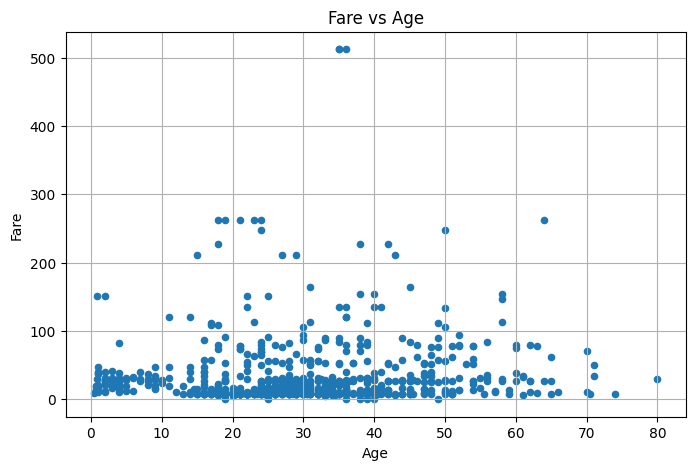

In [28]:
data.plot(kind='scatter', x='Age', y='Fare', title='Fare vs Age', figsize=(8, 5))
plt.grid(True)
plt.show()

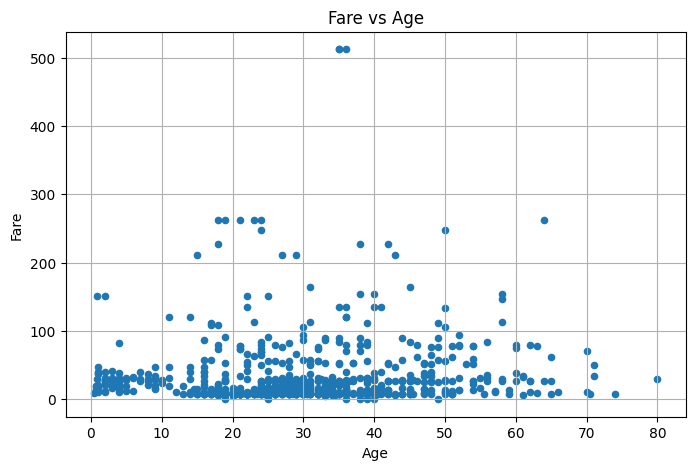

In [32]:
df.plot(kind='scatter', x='Age', y='Fare', title='Fare vs Age', figsize=(8, 5))

plt.grid(True)
plt.show()

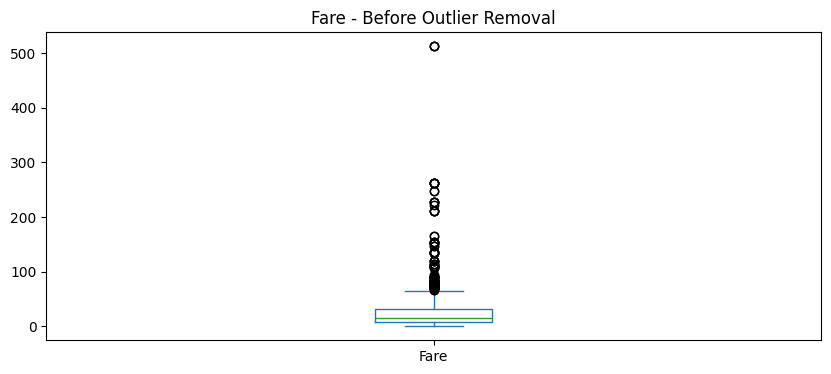

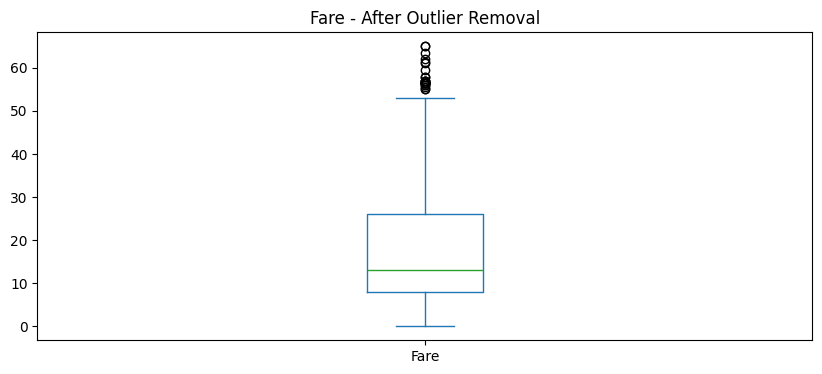

In [34]:
plt.figure(figsize=(10, 4))
df['Fare'].plot(kind='box', title='Fare - Before Outlier Removal')
plt.show()
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Remove outliers
df_no_outliers = df[(df['Fare'] >= lower) & (df['Fare'] <= upper)]
plt.figure(figsize=(10, 4))
df_no_outliers['Fare'].plot(kind='box', title='Fare - After Outlier Removal')
plt.show()